# Patch Extraction and Visualization for MAE

Visualize how images are divided into patches, which is fundamental for the MAE (Masked Autoencoder) preprocessing.

For MAE:
- Images are divided into non-overlapping patches
- Typical patch size: 16×16 pixels (on 224×224 images → 196 patches)
- A random subset (~75%) of patches is masked during training

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'imagenet100'
TRAIN_DIR = DATA_ROOT / 'train'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# MAE hyperparameters
IMAGE_SIZE = 224
PATCH_SIZE = 16
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2  # 14x14 = 196
MASK_RATIO = 0.75  # Mask 75% of patches

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Train dir exists: {TRAIN_DIR.exists()}")
print(f"Image size: {IMAGE_SIZE}")
print(f"Patch size: {PATCH_SIZE}")
print(f"Patches per image: {NUM_PATCHES} ({IMAGE_SIZE // PATCH_SIZE}×{IMAGE_SIZE // PATCH_SIZE})")
print(f"Mask ratio: {MASK_RATIO}")
print(f"Masked patches: {int(NUM_PATCHES * MASK_RATIO)}")
print(f"Visible patches: {int(NUM_PATCHES * (1 - MASK_RATIO))}")

Notebook dir: c:\Users\giova\Universita\deep_learning\Masked-Autoencoders-for-Image-Representation-Learning\notebooks
Project root: c:\Users\giova\Universita\deep_learning\Masked-Autoencoders-for-Image-Representation-Learning
Data root: c:\Users\giova\Universita\deep_learning\Masked-Autoencoders-for-Image-Representation-Learning\data\raw\imagenet100
Train dir exists: True
Image size: 224
Patch size: 16
Patches per image: 196 (14×14)
Mask ratio: 0.75
Masked patches: 147
Visible patches: 49


## Helper functions for patchification

In [6]:
def patchify(image_tensor, patch_size=16):
    """
    Divide image tensor (C, H, W) into non-overlapping patches.
    Returns: (num_patches, patch_size, patch_size, C)
    """
    C, H, W = image_tensor.shape
    assert H % patch_size == 0 and W % patch_size == 0
    
    num_patches_h = H // patch_size
    num_patches_w = W // patch_size
    num_patches = num_patches_h * num_patches_w
    
    # Reshape: (C, H, W) -> (C, num_patches_h, patch_size, num_patches_w, patch_size)
    patches = image_tensor.reshape(C, num_patches_h, patch_size, num_patches_w, patch_size)
    # Permute: (C, num_patches_h, patch_size, num_patches_w, patch_size) -> (num_patches_h, patch_size, num_patches_w, patch_size, C)
    patches = patches.permute(1, 2, 3, 4, 0)
    # Reshape: (num_patches_h, patch_size, num_patches_w, patch_size, C) -> (num_patches, patch_size, patch_size, C)
    patches = patches.reshape(num_patches, patch_size, patch_size, C)
    
    return patches

def generate_mask(num_patches, mask_ratio=0.75):
    """
    Generate random binary mask for patches.
    1 = mask (hide), 0 = visible
    """
    num_masked = int(num_patches * mask_ratio)
    mask = np.zeros(num_patches)
    mask[:num_masked] = 1
    np.random.shuffle(mask)
    return mask.astype(bool)

print("Patchification functions loaded")

Patchification functions loaded


## Load a sample image and visualize patches

In [7]:
# Find first available class with images
if not TRAIN_DIR.exists():
    print(f"TRAIN_DIR does not exist: {TRAIN_DIR}")
else:
    class_dirs = [d for d in TRAIN_DIR.iterdir() if d.is_dir()]
    if not class_dirs:
        print("No class directories found in TRAIN_DIR")
    else:
        class_dir = class_dirs[0]
        image_files = [f for f in class_dir.iterdir() if f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.JPEG'}]
        
        if not image_files:
            print(f"No images found in {class_dir}")
        else:
            # Load first image
            img_path = image_files[0]
            img_pil = Image.open(img_path).convert('RGB')
            
            # Resize to standard size
            img_pil = img_pil.resize((IMAGE_SIZE, IMAGE_SIZE))
            
            # Convert to tensor (C, H, W)
            img_tensor = torch.from_numpy(np.array(img_pil)).permute(2, 0, 1).float() / 255.0
            
            print(f"Loaded image: {img_path.name}")
            print(f"Image shape: {img_tensor.shape}")
            print(f"Image class: {class_dir.name}")

Loaded image: n01440764_10026.JPEG
Image shape: torch.Size([3, 224, 224])
Image class: n01440764


## Extract patches and generate mask

In [8]:
# Patchify
patches = patchify(img_tensor, patch_size=PATCH_SIZE)
print(f"Patches shape: {patches.shape}")
print(f"Patches extracted: {patches.shape[0]}")

# Generate mask
np.random.seed(42)  # For reproducibility
mask = generate_mask(NUM_PATCHES, mask_ratio=MASK_RATIO)
num_masked = mask.sum()
num_visible = (~mask).sum()

print(f"\nMask statistics:")
print(f"  Masked patches: {num_masked}")
print(f"  Visible patches: {num_visible}")
print(f"  Mask ratio (actual): {num_masked / NUM_PATCHES:.2%}")

Patches shape: torch.Size([196, 16, 16, 3])
Patches extracted: 196

Mask statistics:
  Masked patches: 147
  Visible patches: 49
  Mask ratio (actual): 75.00%


## Visualize original image with patch grid

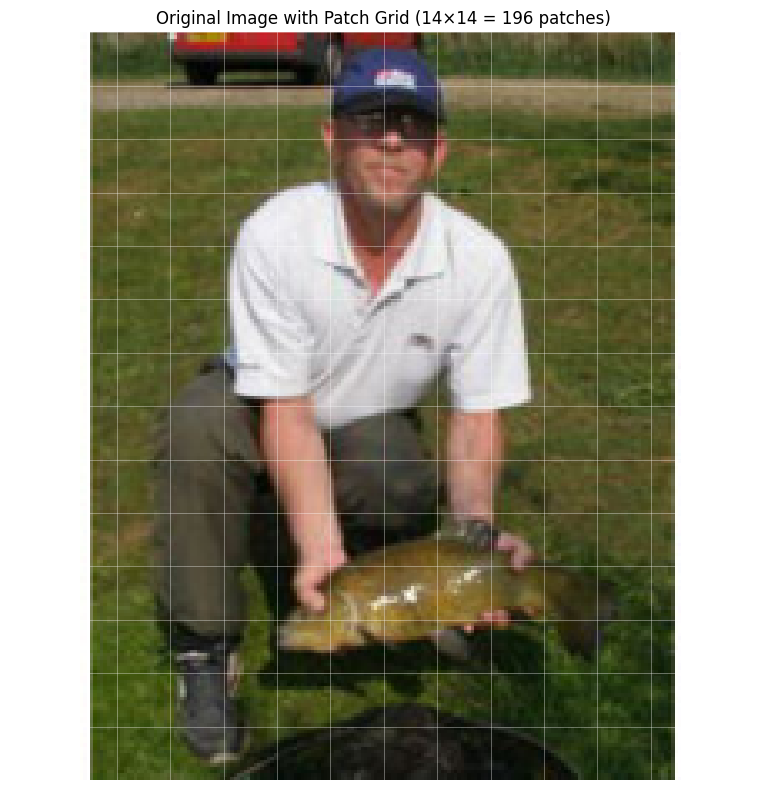

Saved patch grid visualization to c:\Users\giova\Universita\deep_learning\Masked-Autoencoders-for-Image-Representation-Learning\figures\02_patch_grid.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

# Display image
img_display = img_tensor.permute(1, 2, 0).numpy()
ax.imshow(img_display)

# Draw patch grid
num_patches_side = IMAGE_SIZE // PATCH_SIZE
for i in range(num_patches_side + 1):
    ax.axhline(y=i * PATCH_SIZE - 0.5, color='white', linewidth=0.5, alpha=0.5)
    ax.axvline(x=i * PATCH_SIZE - 0.5, color='white', linewidth=0.5, alpha=0.5)

ax.set_title(f"Original Image with Patch Grid ({num_patches_side}×{num_patches_side} = {NUM_PATCHES} patches)")
ax.axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_patch_grid.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Saved patch grid visualization to {FIGURES_DIR / '02_patch_grid.png'}")

## Visualize masked vs visible patches

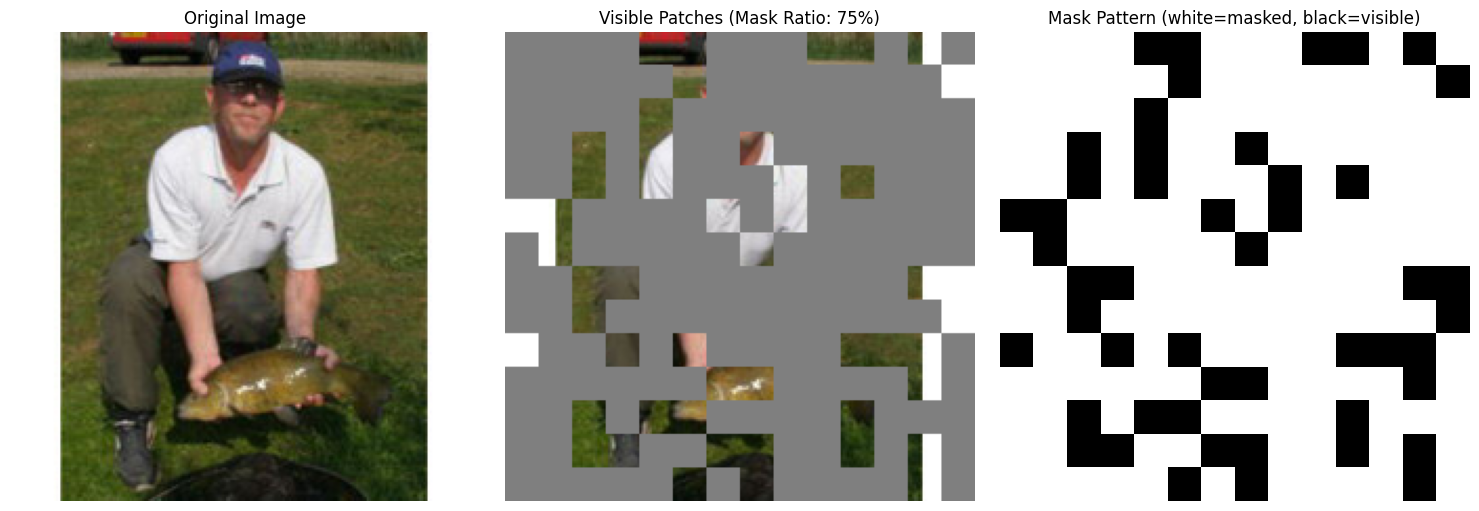

Saved masked/visible visualization to c:\Users\giova\Universita\deep_learning\Masked-Autoencoders-for-Image-Representation-Learning\figures\02_masked_vs_visible.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(img_display)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Visible patches only
visible_image = img_display.copy()
num_patches_side = IMAGE_SIZE // PATCH_SIZE
patch_idx = 0
for i in range(num_patches_side):
    for j in range(num_patches_side):
        if mask[patch_idx]:  # Masked
            y_start = i * PATCH_SIZE
            y_end = (i + 1) * PATCH_SIZE
            x_start = j * PATCH_SIZE
            x_end = (j + 1) * PATCH_SIZE
            visible_image[y_start:y_end, x_start:x_end] = 0.5  # Gray out masked patches
        patch_idx += 1

axes[1].imshow(visible_image)
axes[1].set_title(f'Visible Patches (Mask Ratio: {MASK_RATIO:.0%})')
axes[1].axis('off')

# Mask visualization
mask_grid = mask.reshape(num_patches_side, num_patches_side)
axes[2].imshow(mask_grid, cmap='gray', interpolation='nearest')
axes[2].set_title('Mask Pattern (white=masked, black=visible)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_masked_vs_visible.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Saved masked/visible visualization to {FIGURES_DIR / '02_masked_vs_visible.png'}")

## Visualize individual patches

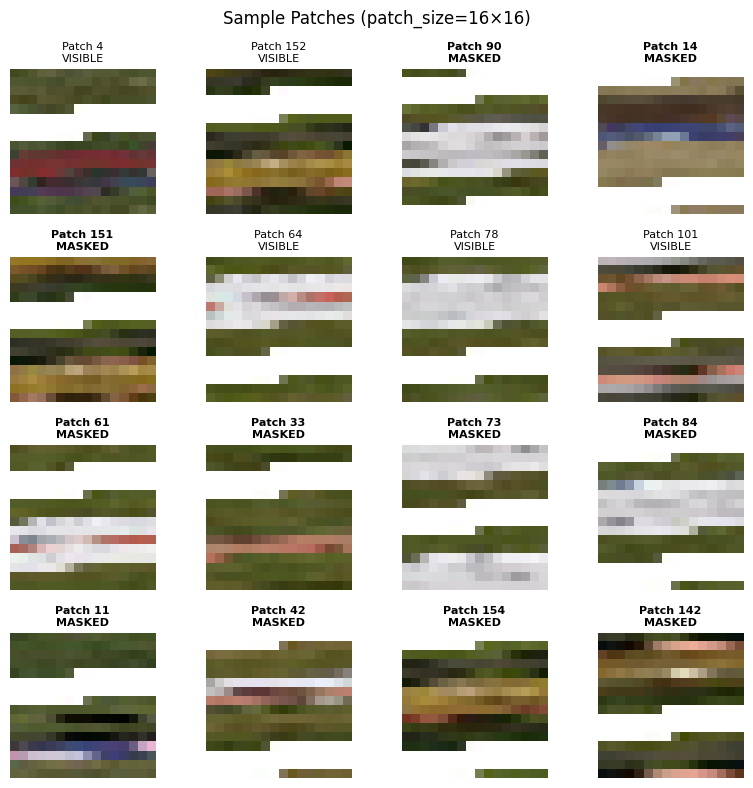

Saved sample patches visualization to c:\Users\giova\Universita\deep_learning\Masked-Autoencoders-for-Image-Representation-Learning\figures\02_sample_patches.png


In [11]:
# Show a grid of random patches
num_patches_to_show = 16
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.flatten()

random_indices = np.random.choice(NUM_PATCHES, min(num_patches_to_show, NUM_PATCHES), replace=False)

for idx, patch_idx in enumerate(random_indices):
    patch = patches[patch_idx].numpy()
    axes[idx].imshow(patch)
    is_masked = mask[patch_idx]
    status = 'MASKED' if is_masked else 'VISIBLE'
    axes[idx].set_title(f"Patch {patch_idx}\n{status}", fontsize=8, fontweight='bold' if is_masked else 'normal')
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(len(random_indices), num_patches_to_show):
    axes[idx].axis('off')

plt.suptitle(f"Sample Patches (patch_size={PATCH_SIZE}×{PATCH_SIZE})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_sample_patches.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Saved sample patches visualization to {FIGURES_DIR / '02_sample_patches.png'}")

## Summary statistics

In [12]:
print("\n=== MAE Preprocessing Summary ===")
print(f"Input Image Size: {IMAGE_SIZE}×{IMAGE_SIZE} pixels")
print(f"Patch Size: {PATCH_SIZE}×{PATCH_SIZE} pixels")
print(f"Patches per Image: {NUM_PATCHES} (arranged as {num_patches_side}×{num_patches_side})")
print(f"Total Patch Dimensions: {NUM_PATCHES} × ({PATCH_SIZE}×{PATCH_SIZE}×3) = {NUM_PATCHES * PATCH_SIZE * PATCH_SIZE * 3} pixels/values")
print(f"\nMasking Configuration:")
print(f"  Mask Ratio: {MASK_RATIO:.0%}")
print(f"  Masked Patches: {int(NUM_PATCHES * MASK_RATIO)}")
print(f"  Visible Patches: {int(NUM_PATCHES * (1 - MASK_RATIO))}")
print(f"\nTraining Strategy:")
print(f"  Encoder sees only visible patches: {int(NUM_PATCHES * (1 - MASK_RATIO))} patches")
print(f"  Decoder reconstructs masked patches: {int(NUM_PATCHES * MASK_RATIO)} patches")
print(f"  Loss computed only on masked patches")


=== MAE Preprocessing Summary ===
Input Image Size: 224×224 pixels
Patch Size: 16×16 pixels
Patches per Image: 196 (arranged as 14×14)
Total Patch Dimensions: 196 × (16×16×3) = 150528 pixels/values

Masking Configuration:
  Mask Ratio: 75%
  Masked Patches: 147
  Visible Patches: 49

Training Strategy:
  Encoder sees only visible patches: 49 patches
  Decoder reconstructs masked patches: 147 patches
  Loss computed only on masked patches
